In [64]:
# Pick the best clustering set

rm(list=ls())

library(dplyr)
library(ConsensusClusterPlus)
library(tibble)
library(survival)
library(survminer)

In [65]:
load("../data/tcga_time_deconv_mcpcounter.RData")
# Data included: res.deconv.epic, df.clinical.bcr, prad.gene, time.epic.bcr

In [66]:
# Pick the (best) deconv set
res.deconv <- res.deconv.mcpcounter

In [67]:
res.deconv

,TCGA.2A.A8VL,TCGA.2A.A8VO,TCGA.2A.A8VT,TCGA.2A.A8VV,TCGA.2A.A8VX,TCGA.2A.A8W1,TCGA.2A.A8W3,TCGA.2A.AAYF,TCGA.2A.AAYO,TCGA.2A.AAYU,⋯,TCGA.ZG.A9LN,TCGA.ZG.A9LS,TCGA.ZG.A9LU,TCGA.ZG.A9LY,TCGA.ZG.A9LZ,TCGA.ZG.A9M4,TCGA.ZG.A9MC,TCGA.ZG.A9N3,TCGA.ZG.A9ND,TCGA.ZG.A9NI
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
T cell,21.516857,31.284693,29.963229,14.926129,20.909443,6.813171,21.555621,19.100164,108.472550,11.879579,⋯,211.725650,148.819179,64.448843,34.988507,43.53843,105.38842,222.25799,76.092843,14.1300857,29.844886
T cell CD8+,26.776500,21.267900,116.544100,19.296400,29.726700,4.249800,22.490300,13.582300,64.499200,60.093100,⋯,220.451400,81.037300,41.441000,34.716300,51.78840,121.31570,98.09810,34.927900,13.8337000,13.526800
NK cell,2.639012,3.240038,2.297775,1.647238,2.015375,0.649275,2.606812,1.432513,9.242262,1.110875,⋯,8.483375,4.153162,4.709213,2.063938,3.21350,8.75695,5.25525,2.054575,0.6916875,2.066600
B cell,44.863537,39.212700,16.590062,75.773612,1046.605362,38.720337,18.401138,53.798800,335.736750,108.760063,⋯,715.940600,207.252825,20.014125,48.475862,50.48434,91.20034,400.77579,441.991512,899.6195750,8.923937
Monocyte,249.448286,155.046786,322.716914,312.977986,338.721314,142.941486,218.301843,125.151586,310.435257,801.765314,⋯,512.380757,440.842786,254.162600,416.463057,605.16181,201.86733,476.47649,201.348829,106.9143571,295.550214
Macrophage/Monocyte,249.448286,155.046786,322.716914,312.977986,338.721314,142.941486,218.301843,125.151586,310.435257,801.765314,⋯,512.380757,440.842786,254.162600,416.463057,605.16181,201.86733,476.47649,201.348829,106.9143571,295.550214
Myeloid dendritic cell,15.756960,34.560320,16.470580,21.649600,15.115260,8.027400,26.415860,21.392160,68.379660,18.366480,⋯,177.858900,121.880040,54.438420,41.236240,38.45006,106.87740,116.11610,33.489660,14.3870200,33.666740
Neutrophil,908.170267,678.224440,1224.485287,2050.186287,514.657593,1632.424353,929.380493,1030.984720,487.537153,1239.779940,⋯,568.368407,394.651553,535.217000,714.366367,1660.73026,603.78757,863.22989,560.626387,1752.5390600,459.160293
Endothelial cell,252.327497,270.050047,250.077457,307.563870,120.030730,97.072847,460.685487,212.203317,378.481570,172.202850,⋯,319.238640,591.346303,310.560867,399.591727,230.90313,592.98162,512.83733,180.739343,263.2864200,569.346480


In [68]:
# Scale: z-score transformation --- 0 mean 1 deviation
res.deconv.scale <- t(scale(t(res.deconv)))

In [69]:
res.deconv.scale

,TCGA.2A.A8VL,TCGA.2A.A8VO,TCGA.2A.A8VT,TCGA.2A.A8VV,TCGA.2A.A8VX,TCGA.2A.A8W1,TCGA.2A.A8W3,TCGA.2A.AAYF,TCGA.2A.AAYO,TCGA.2A.AAYU,⋯,TCGA.ZG.A9LN,TCGA.ZG.A9LS,TCGA.ZG.A9LU,TCGA.ZG.A9LY,TCGA.ZG.A9LZ,TCGA.ZG.A9M4,TCGA.ZG.A9MC,TCGA.ZG.A9N3,TCGA.ZG.A9ND,TCGA.ZG.A9NI
T cell,-0.5462404,-0.29798114,-0.3315675,-0.71375025,-0.56167839,-0.9199491,-0.5452551,-0.60766300,1.6638247,-0.79118134,⋯,4.2881045,2.6892742,0.5449186,-0.2038450,0.01345969,1.5854385,4.55579441,0.8408624,-0.7339825,-0.3345753
T cell CD8+,-0.5451612,-0.67186080,1.5195227,-0.71720594,-0.47730565,-1.0632826,-0.6437452,-0.84863209,0.3224731,0.22113140,⋯,3.9094243,0.7028548,-0.2078730,-0.3625432,0.03012061,1.6292711,1.09525873,-0.3576764,-0.8428498,-0.8499086
NK cell,-0.1057110,0.06204282,-0.2009549,-0.38252830,-0.27977636,-0.6610726,-0.1146985,-0.44246084,1.7373416,-0.53223403,⋯,1.5255263,0.3169078,0.4721086,-0.2662219,0.05463586,1.6018846,0.62451476,-0.2688351,-0.6492347,-0.2654788
B cell,-0.3979204,-0.42668718,-0.5418526,-0.24056599,4.70166173,-0.4291937,-0.5326329,-0.35243350,1.0828322,-0.07264138,⋯,3.0183417,0.4287572,-0.5244217,-0.3795311,-0.36930648,-0.1620329,1.41392744,1.6237450,3.9533990,-0.5808786
Monocyte,-0.4918881,-0.95154710,-0.1351291,-0.18254978,-0.05720058,-1.0104901,-0.6435461,-1.09711256,-0.1949308,2.19744951,⋯,0.7883806,0.4400485,-0.4689332,0.3213389,1.24014934,-0.7235689,0.61355579,-0.7260936,-1.1859131,-0.2674089
Macrophage/Monocyte,-0.4918881,-0.95154710,-0.1351291,-0.18254978,-0.05720058,-1.0104901,-0.6435461,-1.09711256,-0.1949308,2.19744951,⋯,0.7883806,0.4400485,-0.4689332,0.3213389,1.24014934,-0.7235689,0.61355579,-0.7260936,-1.1859131,-0.2674089
Myeloid dendritic cell,-0.9477630,-0.31062169,-0.9235823,-0.74809417,-0.96950659,-1.2096747,-0.5865921,-0.75681737,0.8353276,-0.85934084,⋯,4.5449700,2.6481578,0.3629365,-0.0844119,-0.17882004,2.1398018,2.45284996,-0.3469004,-0.9941826,-0.3409001
Neutrophil,-0.2740564,-0.74969196,0.3802312,2.08816732,-1.08802476,1.2240401,-0.2301837,-0.02001858,-1.1441225,0.41186766,⋯,-0.9769257,-1.3362534,-1.0454983,-0.6749335,1.28258996,-0.9036623,-0.36701409,-0.9929398,1.4724935,-1.2028192
Endothelial cell,-0.5606075,-0.45603127,-0.5738844,-0.23467172,-1.34125716,-1.4767258,0.6688601,-0.79737013,0.1837956,-1.03340273,⋯,-0.1657819,1.4398564,-0.2169872,0.3083613,-0.68702730,1.4495060,0.97659486,-0.9830310,-0.4959417,1.3100410
Cancer associated fibroblast,-0.3860825,-0.17880960,-0.7497519,0.06502287,-0.23526900,-1.0435170,-0.3718819,-0.51694211,0.2660976,-0.07234647,⋯,0.9304643,1.4005660,-0.1021182,0.2487833,-0.59169740,-0.7157716,0.09817695,-0.1561324,-0.6722322,1.7438178


In [73]:
# Clustering
results.tcga <- ConsensusClusterPlus(res.deconv.scale, maxK=6, reps=1000, pItem=0.8, pFeature=1, title="../output/Consensus_clustering_mcpcounter_pam_pearson_average_tcga", 
                                     clusterAlg="pam", distance="pearson", seed=123456, plot="pdf")

end fraction

clustered

clustered

clustered

clustered

clustered



In [74]:
res.deconv.sample <- as.data.frame(t(res.deconv.scale))

In [75]:
# add "bcr_months" column
df.clinical.bcr$bcr_months <- df.clinical.bcr$bcr_days/30

In [76]:
# ======== Survival analysis with 3 clusters =============
cluster <- unname(results.tcga[[3]][["consensusClass"]])

cluster[which(cluster == "1")] <- "good"
cluster[which(cluster == "2")] <- "mediate"
cluster[which(cluster == "3")] <- "bad"

cluster <- factor(cluster, levels = c("good", "mediate", "bad"))

In [77]:
change_cluster_name <- function(old.names, old.levels = c("good", "mediate", "bad"), new.levels = c("TCE", "TuCE", "TASCE")) {
  new.names <- as.character(old.names)
  
  for (i in seq(1, length(old.levels))){
    new.names[which(new.names == old.levels[i])] <- new.levels[i]
  }
  
  new.names <- factor(new.names, levels = new.levels)
  
  return(new.names)
}

In [78]:
new.levels <- c("TCE", "EPCE", "TASCE")

cluster <- change_cluster_name(cluster, old.levels = c("good", "mediate", "bad"), new.levels)

res.deconv.sample$cluster <- cluster

In [79]:
df.clinical.bcr.cluster <- merge(df.clinical.bcr, res.deconv.sample, by = "row.names")
df.clinical.bcr.cluster <- column_to_rownames(df.clinical.bcr.cluster, colnames(df.clinical.bcr.cluster)[1])

df.clinical.bcr.cluster$bcr_months <- as.numeric(df.clinical.bcr.cluster$bcr_months)
df.clinical.bcr.cluster$biochemical_recurrence <- 1*(df.clinical.bcr.cluster$biochemical_recurrence=="YES")

In [80]:
# draw the Surv curve of TCGA's 3 clusters
# options(repr.plot.width=6, repr.plot.height=5.5)

# load color palette
source("color_palette.R")

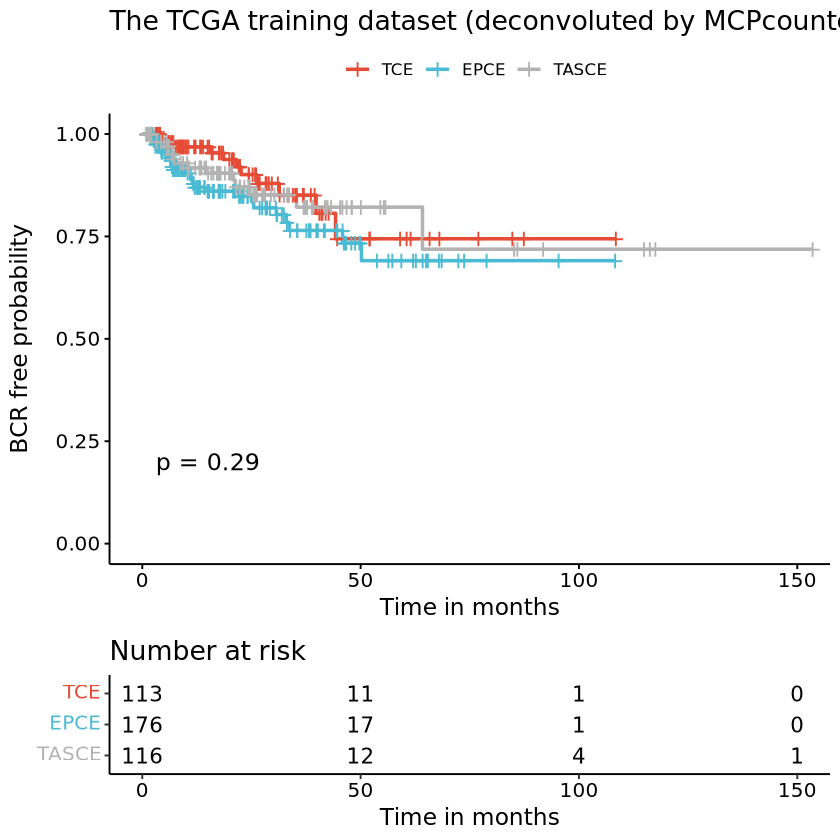

In [81]:
km.fit <- survminer::surv_fit(Surv(bcr_months, biochemical_recurrence) ~ cluster, data=df.clinical.bcr.cluster)
p.surv <- survminer::ggsurvplot(km.fit, pval = TRUE, risk.table = TRUE, ncensor.plot = FALSE,
                                title = "The TCGA training dataset (deconvoluted by MCPcounter)",
                                palette = color.three.clusters,
                                legend.title = "", legend.labs = c("TCE", "EPCE", "TASCE"),
                                xlab = "Time in months", ylab = "BCR free probability")
print(p.surv)

In [82]:
res.deconv.tcga <- res.deconv
res.deconv.scale.tcga <- res.deconv.scale
res.deconv.sample.tcga <- res.deconv.sample

In [83]:
patients.outlier <- rownames(df.clinical.bcr.cluster %>% filter(cluster == new.levels[1] & biochemical_recurrence == "1" & bcr_days > 1000))
print(patients.outlier)

[1] "TCGA.KC.A4BV" "TCGA.VP.A87D"


In [84]:
df.clinical.bcr.cluster <- df.clinical.bcr.cluster[!(rownames(df.clinical.bcr.cluster) %in% patients.outlier), ]

patients.keep <- rownames(df.clinical.bcr.cluster)

# update the other variables' patients
res.deconv.tcga <- res.deconv.tcga[, patients.keep]
res.deconv.scale.tcga <- res.deconv.scale.tcga[, patients.keep]
res.deconv.sample.tcga <- res.deconv.sample.tcga[patients.keep, ]

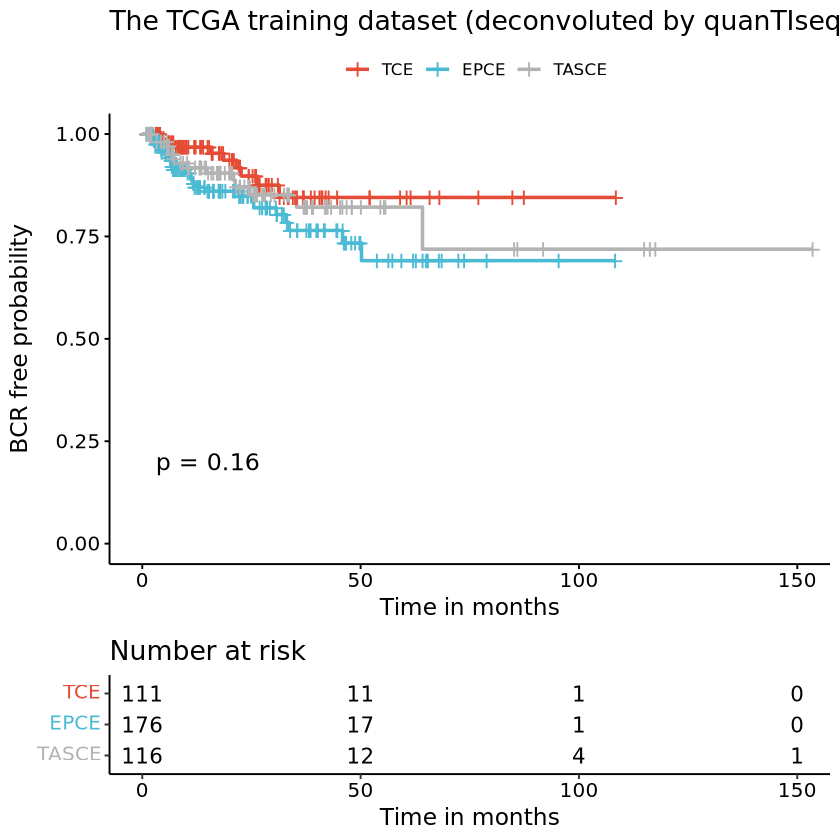

In [85]:
km.fit <- survminer::surv_fit(Surv(bcr_months, biochemical_recurrence) ~ cluster, data=df.clinical.bcr.cluster)
p.surv <- survminer::ggsurvplot(km.fit, pval = TRUE, risk.table = TRUE, ncensor.plot = FALSE,
                                title = "The TCGA training dataset (deconvoluted by quanTIseq",
                                palette = color.three.clusters,
                                legend.title = "", legend.labs = c("TCE", "EPCE", "TASCE"),
                                xlab = "Time in months", ylab = "BCR free probability")
print(p.surv)

In [86]:
# save the data
save(res.deconv.tcga, res.deconv.scale.tcga, res.deconv.sample.tcga, df.clinical.bcr.cluster, file = "../data/clustering_tcga_removing_badguys_mcpcounter.RData")